<a href="https://colab.research.google.com/github/nyp-sit/dit-it3103/blob/main/week5/yolo11_custom_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT3103 Practical 05: Object Detection using YOLO

Welcome to this week's hands-on lab. In this lab, we are going to learn how to train a balloon detector!

At the end of this exercise, you will be able to:

- create an object detection dataset in YOLO format
- finetune a YOLO11 pretrained model with the custom dataset
- monitor the training progress and evaluation metrics
- deploy the trained model for object detection

## Create an object detection dataset

We will use a sample balloon dataset to illustrate the process of annotation and packaga the dataset in different format for object detection (e.g. YOLO, Pascal VOC, COCO, etc).

To annotate, there are many different tools available, such as the very basic [LabelImg](https://github.com/HumanSignal/labelImg) , or the more feature-packed tool such as [Label Studio](https://labelstud.io/), or online service such as [Roboflow](https://roboflow.com/).

### Raw Image Dataset

You can download the balloon images (without annotations) from [this link](https://github.com/nyp-sit//dit-it3103/raw/refs/heads/main/data/balloon_raw_dataset.zip).

Unzip the file to a local folder.

There are total of 74 images. You should divide the images into both training and validation set (e.g. 80%-20%, i.e. 59 images for train, and 15 for test).


### Option 1: Label Studio

You can follow the [steps](https://labelstud.io/guide/quick_start) here to setup Label Studio on your PC. It is recommended to setup a conda environment before you install the Label Studio.  

Here are the steps that need to be done:
1. Create a new Project
2. Import the images into Label Studio
3. Set up the Labelling UI tempalte (choose Object Detection with Bounding Box template)
4. Export the dataset in YOLO format.

The exported dataset will have the following folder structure:
```
<root folder>
classes.txt    --> contains the labels, with each class label on a new line
--images --> contains the images
--labels --> contains the annotations (i.e. bbox coordinates)
notes.json --> some info about this dataset (i.e. not used)
```

For training with Ultralytics, you need to organize the files into train and validate (and optionally test) folders, and to create a data.yaml file to provide information about the folder location of test and validation set:

```
<root folder>
--train
----images
----labels
--valid
----images
----labels
data.yaml
```

The data.yaml file should specify the following:
```
train: ../train/images
val: ../valid/images
test: ../test/images

names:
    0: balloon
```

If you have more than one class of object to detect, specify the rest of the names under the names field.


### Option 2: Roboflow

You can aso create a new account with [Roboflow](https://roboflow.com/). Roboflow integrates very well with Ultralytics and you can easily export the dataset in a format recognized by Ultralytics trainer (for YOLO model)

Similarly, you can create a new account, upload all the raw images, annotate them and then export.

You can choose the format to be YOLOv8 and choose local directory to download the dataset locally instead of pushing it to the Roboflow universal wish.

Here is a [introductory blog](https://blog.roboflow.com/getting-started-with-roboflow/) on using the Roboflow to annotate.





### Option 3: Auto Labelling using Grounding DINO

Both Label Studio and Roboflow supports the use of Grounding DINO to auto label the dataset.

Grounding DINO is open-set object detector, marrying Transformer-based detector DINO with grounded pre-training, which can detect arbitrary objects with human inputs (prompts) such as category names or referring expressions.

###Label Studio

You can follow the instruction [here](https://labelstud.io/blog/using-text-prompts-for-image-annotation-with-grounding-dino-and-label-studio/)  to setup the Grounding DINO ML backend to integrate with your label studio.

###Roboflow

Here is a [video tutorial](https://youtu.be/SDV6Gz0suAk) on using Grounding DINO with Roboflow.


### Download Annotated Dataset

To save you time for this lab, you can download a pre-annotated balloon dataset [here](https://github.com/nyp-sit/dit-it3103/raw/refs/heads/main/data/balloon_annotated_dataset.zip).

We download and unzip to the directory called `datasets`



In [1]:
%%capture
%%bash
wget https://github.com/nyp-sit/dit-it3103/raw/refs/heads/main/data/balloon_annotated_dataset.zip
mkdir -p datasets
unzip balloon_annotated_dataset.zip -d datasets/

Let's verify the dataset structure and examine the `data.yaml` file, which tells the YOLO trainer where to find the images and what classes to detect.

In [2]:
!cat datasets/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['balloon']

roboflow:
  workspace: kheng-kok-mar-504hc
  project: balloon-project-bvwfu
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/kheng-kok-mar-504hc/balloon-project-bvwfu/dataset/1

In [3]:
%%capture
!pip install ultralytics

## Training the Model

YOLOv11 comes with different sizes of pretrained models: yolov11n, yolov11s, .... The differs in terms of their sizes, inference speeds and precision:

<img src="https://github.com/nyp-sit/it3103-2025s2/blob/main/week4/assets/yolo11-models.png?raw=true" width="70%"/>

We will use the small pretrained model yolo11s and finetune it on our custom dataset.


### Setup the logging

Ultralytics support logging to wandb, comet.ml and tensorboard, out of the box. Here we only enable wandb.

You need to create an account at [wandb](https://wandb.ai) and get the API key from https://wandb.ai/authorize.


In [4]:
from ultralytics import settings

settings.update({"wandb": True,
                 "tensorboard": False})

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Training

We specify the path to data.yaml file, and train with a batch size of 15, and we also save the checkpoint at each epoch (save_period=1). We assume here you are connected to a GPU, hence we can specify the device to use as `device=0` to select the first GPU.  We specify the project name as balloon, this will create a folder called `balloon` to store the weights and various training artifacts such as F1, PR curves, confusion matrics, training results (loss, mAP, etc).

For a complete listing of train settings, you can see [here](https://docs.ultralytics.com/modes/train/#train-settings).

You can also specify the type of data [augmentation](https://docs.ultralytics.com/modes/train/#augmentation-settings-and-hyperparameters)  you want as part of the train pipeline.

You can monitor your training progress at wandb (the link is given in the train output below)


In [5]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")  # Load a pre-trained YOLO model
result = model.train(data="datasets/data.yaml",
                     epochs=30,
                     save_period=1,
                     batch=16,
                     device=0,
                     project='balloon',
                     plots=True)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chrysliang25 (chrysliang25-nyp) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

lr/pg0,▁▂▃▄▄▅▆▆▇▇▇████████▇▇▇▆▆▅▅▄▃▂▁
lr/pg1,▁▂▃▄▄▅▆▆▇▇▇████████▇▇▇▆▆▅▅▄▃▂▁
lr/pg2,▁▂▃▄▄▅▆▆▇▇▇████████▇▇▇▆▆▅▅▄▃▂▁
metrics/mAP50(B),▂▄█▇▇▇▇█▇▇▇▇▄▁▁▁▁█████████████
metrics/mAP50-95(B),▂▄▇▆▇▇▇▇▇▇▇▇▄▁▁▁▁▇██▇▇▇███████
metrics/precision(B),▄▅▇▆▇▇▇████▇▃▁▁▁▁▇▇▇▇█████▇▇█▇
metrics/recall(B),▁▃▇▆▆▇▇▆▆▆▆▇▅▆▄▃▇████▇▇▇▇▇████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


You can see the various graphs in your wandb dashboard, for example:

*metrics*

<img src="https://github.com/nyp-sit/it3103-2025s2/blob/main/week4/assets/wandb-metrics.png?raw=true"/>

*Train and validation loss*

<img src="https://github.com/nyp-sit/it3103-2025s2/blob/main/week4/assets/wandb-loss.png?raw=true"/>

You can go to the folder `balloon-->train-->weights` and you will files like epoch0.pt, epoch1.pt, .... and also best.pt.
The epoch0.pt, epoch1.pt are the checkpoints that are saved every period (in our case, we specify period as 1 epoch).  The best.pt contains the best checkpoint.

We can run the best model (using the best checkpoint) against the validation dataset to see the overall model performance on validation set.  

You should see around `0.88` for `mAP50`, and `0.78` for `mAP50-95`.

In [6]:
from ultralytics import YOLO

model = YOLO("runs/detect/balloon/train/weights/best.pt")
validation_results = model.val(data="datasets/data.yaml", device="0")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2590.1±768.2 MB/s, size: 244.2 KB)
val: Scanning /content/datasets/valid/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 5.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.6s
                   all         15         71      0.907      0.827      0.895      0.802
Speed: 1.9ms preprocess, 12.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val


## Export and Deployment

Your model is in pytorch format (.pt). You can export the model to various format, e.g. TorchScript, ONNX, OpenVINO, TensorRT, etc. depending on your use case, and deployment platform (e.g. CPU or GPU, etc)

You can see the list of [supported formats](https://docs.ultralytics.com/modes/export/#export-formats)  and the option they support in terms of further optimization (such as imagesize, int8, half-precision, etc) in the ultralytics site.

Ultralytics provide a utility function to benchmark your model using different supported formats automatically. You can uncomment the code in the following code cell to see the benchmark result. If you are benchmarking for CPU only, the change the `device=0` to `device='cpu'`.  

**Beware: it will take quite a while to complete the benchmark**

In [ ]:
# from ultralytics.utils.benchmarks import benchmark

# # Benchmark on GPU (device=0 means the 1st GPU device)
# benchmark(model="balloon/train/weights/best.pt", data="datasets/data.yaml", imgsz=640, half=False, device=0)


In the following code, we export it as OpenVINO. OpenVINO is optimized for inference on Intel CPUs and since we will use the model later on to do inference on local Windows machine (which runs Intel chip), we will export it as OpenVINO format. We also specify using int8 quantization, which results in faster inference, at the cost of accuracy.

For more information on OpenVINO, go to the [official documentation](https://docs.openvino.ai/2024/index.html).

After export, you can find the openvino model in `balloon\train\weights\best_openvino_model` directory.

In [7]:
model = YOLO("runs/detect/balloon/train/weights/best.pt")
exported_path = model.export(format="openvino", int8=True)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'runs/detect/balloon/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.3 MB)
requirements: Ultralytics requirement ['openvino>=2024.0.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 3 packages in 255ms
Prepared 2 packages in 972ms
Installed 2 packages in 56ms
 + openvino==2026.1.0
 + openvino-telemetry==2025.2.0

requirements: AutoUpdate success ✅ 1.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics re

Output()

Output()

OpenVINO: export success ✅ 22.2s, saved as 'runs/detect/balloon/train/weights/best_int8_openvino_model/' (9.8 MB)

Export complete (23.1s)
Results saved to /content/runs/detect/balloon/train/weights/best_int8_openvino_model
Predict:         yolo predict task=detect model=runs/detect/balloon/train/weights/best_int8_openvino_model/ imgsz=640 int8
Validate:        yolo val task=detect model=runs/detect/balloon/train/weights/best_int8_openvino_model/ imgsz=640 data=datasets/data.yaml int8 
Visualize:       https://netron.app


## Inference

Let's test our model on some sample pictures. You can optionally specify the confidence threshold (e.g. `conf=0.5`), and the IoU (e.g. `iou=0.6`) for the NMS. The model will only output the bounding boxes of those detection that exceeds the confidence threshould and the IoU threshold.  

Loading runs/detect/balloon/train/weights/best_int8_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /content/sample_balloon.jpeg: 640x640 4 balloons, 242.4ms
Speed: 8.7ms preprocess, 242.4ms inference, 23.8ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'balloon'}
obb: None
orig_img: array([[[247, 253, 236],
        [247, 253, 236],
        [247, 252, 237],
        ...,
        [251, 251, 251],
        [251, 251, 251],
        [251, 251, 251]],

       [[247, 253, 236],
        [247, 253, 236],
        [248, 253, 238],
        ...,
        [251, 251, 251],
        [251, 251, 251],
        [251, 251, 251]],

       [[247, 252, 237],
        [248, 253, 238],
        [248, 253, 238],
        ...,
        [251, 251, 251],
        [251, 251, 251],
        [251, 251, 251]],

       

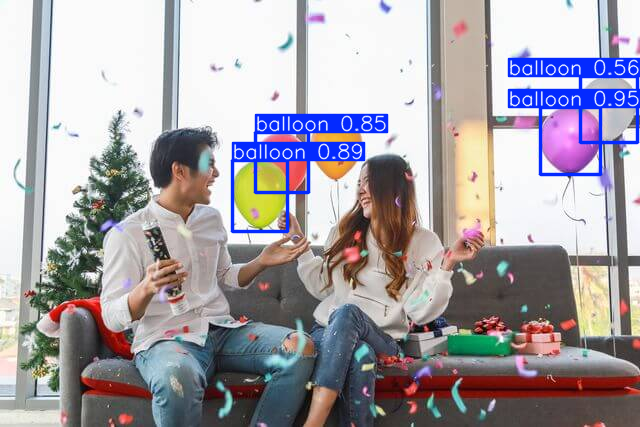

In [8]:
import ultralytics
from ultralytics import YOLO
from PIL import Image

source = 'https://github.com/nyp-sit/dit-it3103/raw/refs/heads/main/data/sample_balloon.jpeg'
model = YOLO("runs/detect/balloon/train/weights/best_int8_openvino_model", task='detect')
result = model(source, conf=0.5, iou=0.6)

# Visualize the results
for i, r in enumerate(result):
    print(r)
    # Plot results image
    im_bgr = r.plot()  # BGR-order numpy array
    im_rgb = Image.fromarray(im_bgr[..., ::-1])  # RGB-order PIL image

    # Show results to screen (in supported environments)
    r.show()

    # Save results to disk
    r.save(filename=f"results{i}.jpg")

## Exercise 1: Compare YOLO Model Sizes

YOLO11 comes in different sizes: `yolo11n` (nano), `yolo11s` (small), `yolo11m` (medium), `yolo11l` (large), `yolo11x` (extra-large). Larger models are more accurate but slower.

Train the **nano** model (`yolo11n.pt`) on the same balloon dataset and compare with the small model (`yolo11s.pt`) we trained earlier:
- Compare `mAP50` and `mAP50-95` on the validation set
- Compare inference speed
- Which model would you choose for a real-time application vs a high-accuracy application?

<details>
<summary>Click here for answer</summary>

```python
from ultralytics import YOLO

# Train nano model
model_nano = YOLO('yolo11n.pt')
result_nano = model_nano.train(
    data='datasets/data.yaml',
    epochs=30,
    batch=16,
    device=0,
    project='balloon_nano',
    plots=True)

# Evaluate nano model
model_nano_best = YOLO('runs/detect/balloon_nano/train/weights/best.pt')
val_nano = model_nano_best.val(data='datasets/data.yaml')
print(f'Nano  - mAP50: {val_nano.box.map50:.4f}, mAP50-95: {val_nano.box.map:.4f}')

# Compare with small model
model_small_best = YOLO('runs/detect/balloon/train/weights/best.pt')
val_small = model_small_best.val(data='datasets/data.yaml')
print(f'Small - mAP50: {val_small.box.map50:.4f}, mAP50-95: {val_small.box.map:.4f}')

# Speed comparison
import time
source = 'https://github.com/nyp-sit/dit-it3103/raw/refs/heads/main/data/sample_balloon.jpeg'

start = time.time()
for _ in range(10):
    model_nano_best(source, verbose=False)
print(f'Nano avg inference: {(time.time()-start)/10*1000:.1f} ms')

start = time.time()
for _ in range(10):
    model_small_best(source, verbose=False)
print(f'Small avg inference: {(time.time()-start)/10*1000:.1f} ms')
```

You should observe:
- Nano is faster but has slightly lower mAP
- Small is more accurate but slower
- For real-time applications (e.g., video streaming), nano is preferred
- For high-accuracy applications (e.g., medical imaging), larger models are preferred

</details>

In [ ]:
## TODO: Train yolo11n.pt on the same balloon dataset
##       Use project='balloon_nano' to save results separately



In [ ]:
## TODO: Compare mAP and inference speed between nano and small models



## Streaming

We can also do real-time detection on a video or camera steram.

*Note: If you encountered error message "NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968", uncomment the following cell and run it.*


In [ ]:
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

### Video File

You need openCV to run the following code.  In your conda environment, install opencv for python using the following command:

```
pip3 install opencv-python
```
or
```
conda install opencv
```

Let's donwload the sample video file.

In [9]:
!wget https://github.com/nyp-sit/dit-it3103/raw/refs/heads/main/data/balloon.mp4

--2026-05-20 05:19:08--  https://github.com/nyp-sit/dit-it3103/raw/refs/heads/main/data/balloon.mp4
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/nyp-sit/dit-it3103/refs/heads/main/data/balloon.mp4 [following]
--2026-05-20 05:19:08--  https://raw.githubusercontent.com/nyp-sit/dit-it3103/refs/heads/main/data/balloon.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3932573 (3.8M) [application/octet-stream]
Saving to: ‘balloon.mp4’

balloon.mp4         100%[===================>]   3.75M  --.-KB/s    in 0.05s   

2026-05-20 05:19:09 (73.0 MB/s) - ‘balloon.mp4’ saved [3932573/3932573]



### Detect and write to a video file

In [13]:
from ultralytics import YOLO
import cv2
from tqdm import tqdm

def write_video(video_in_filepath, video_out_filepath, model):
    # Open the video file

    video_reader = cv2.VideoCapture(video_in_filepath)

    nb_frames = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_h = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_w = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    fps = video_reader.get(cv2.CAP_PROP_FPS)

    video_writer = cv2.VideoWriter(video_out_filepath,
                            cv2.VideoWriter_fourcc(*'mp4v'),
                            fps,
                            (frame_w, frame_h))

    # Loop through the video frames
    for i in tqdm(range(nb_frames)):
        # Read a frame from the video
        success, frame = video_reader.read()

        if success:
            # Run YOLO inference on the frame on GPU Device 0
            results = model(frame, device=0)

            # Visualize the results on the frame
            annotated_frame = results[0].plot()

            # Write the annotated frame
            video_writer.write(annotated_frame)

    video_reader.release()
    video_writer.release()

In [14]:
from pathlib import Path
import os

video_in_file = "balloon.mp4"
basename = Path(video_in_file).stem
video_out_file = os.path.join(basename + '_detected' + '.mp4')
model = YOLO("runs/detect/balloon/train/weights/best_int8_openvino_model", task="detect")
write_video(video_in_file, video_out_file, model)

  0%|          | 0/121 [00:00<?, ?it/s]

Loading runs/detect/balloon/train/weights/best_int8_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

0: 640x640 2 balloons, 160.0ms
Speed: 6.9ms preprocess, 160.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


  1%|          | 1/121 [00:00<01:33,  1.28it/s]


0: 640x640 2 balloons, 172.9ms
Speed: 7.8ms preprocess, 172.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


  2%|▏         | 2/121 [00:00<00:51,  2.29it/s]

...

 98%|█████████▊| 119/121 [00:25<00:00,  5.23it/s]


0: 640x640 (no detections), 167.1ms
Speed: 3.2ms preprocess, 167.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


 99%|█████████▉| 120/121 [00:25<00:00,  5.26it/s]


0: 640x640 2 balloons, 167.2ms
Speed: 4.1ms preprocess, 167.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 121/121 [00:25<00:00,  4.73it/s]


### Streaming and display video (Run in a local PC)

If you are training your model locally, then the exported model should already be on your local PC.

If you are training your model on Google Colab, you will download the exported OpenVINO model to a local PC. Run the following code to zip up the OpenVINO folder and download to local PC.

In [ ]:
%%bash
mv ./runs/detect/balloon/train/weights/best_int8_openvino_model/ .
zip -r best_int8_openvino_model.zip best_int8_openvino_model

# Now go to best_openvino_model to download the best_openvino_model.zip file

**The code below uses openCV library to display video in a window, and can only be run locally on a local laptop.**

In [ ]:
from ultralytics import YOLO
import cv2

# Load the YOLO model
model = YOLO("best_int8_openvino_model", task="detect")

# Open the video file
video_path = "balloon.mp4"
cap = cv2.VideoCapture(video_path)

# Loop through the video frames
while cap.isOpened():
    # Read a frame from the video
    success, frame = cap.read()

    if success:
        # Run YOLO inference on the frame on GPU Device 0
        results = model(frame, device="cpu")

        # Visualize the results on the frame
        annotated_frame = results[0].plot()

        # Display the annotated frame
        cv2.imshow("YOLO Inference", annotated_frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        # Break the loop if the end of the video is reached
        break

# Release the video capture object and close the display window
cap.release()
cv2.destroyAllWindows()